<a href="https://colab.research.google.com/github/Abhinaytechie/LangGraph/blob/main/Summary_Chatbot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install langchain langchain-groq langchain_core langgraph

INFO: pip is looking at multiple versions of langchain-groq to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.4/155.4 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.1/46.1 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.8/56.8 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.6/207.6 kB 15.5 MB/s eta 0:00:00


In [ ]:
from langchain_core.messages import HumanMessage,AIMessage,SystemMessage
from langchain_groq import ChatGroq
from google.colab import userdata
from langchain_core.messages import RemoveMessage
from langgraph.graph import MessagesState,StateGraph,START,END
from pprint import pprint
from typing_extensions import TypedDict
from typing import Literal
from IPython.display import Image, display
from langgraph.checkpoint.memory import MemorySaver

In [ ]:
api_key=userdata.get("GROQ_API_KEY")

llm=ChatGroq(groq_api_key=api_key,model="llama-3.3-70b-versatile")

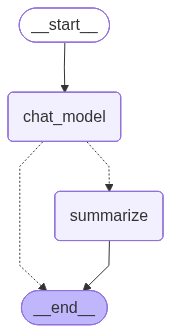

In [ ]:
class State(MessagesState):
  summary:str

def chat_model(state: State):
  summary=state.get("summary","")
  print(summary)
  if summary:
    msg = (
            "You are the AI assistant continuing a chat with the same user. "
            "Below is a factual summary of what has been discussed so far. "
            "Treat this as true and use it to maintain continuity.\n\n"
            f"---\n{summary}\n---"
        )
    message=[SystemMessage(content=msg)]+state['messages']
  else:
    message=state['messages']

  results=llm.invoke(message)
  return {'messages':[results]}

def summarize(state: State):
  summary=state.get("summary","")
  if summary:
   msg = (
            "Update the existing summary of this chat. "
            "Be explicit about who said what. "
            "Always refer to the human as 'the user' and the assistant as 'the AI'. "
            "For example, write 'The user's name is Lance' instead of 'You introduced yourself as Lance'. "
            f"Here is the current summary:\n\n{summary}\n\n"
            "Now extend it based on the latest conversation."
        )

  else:
     msg = (
            "Summarize the conversation. "
            "Be explicit about who said what. "
            "Refer to the human as 'the user' and the assistant as 'the AI'. "
            "Example: 'The user's name is Lance' instead of 'You introduced yourself as Lance'."
        )
  message=state['messages']+[HumanMessage(content=msg)]
  results=llm.invoke(message)

  delete_msgs=[RemoveMessage(id=m.id) for  m in state['messages'][:-2]]
  return{'summary':results.content,"messages":delete_msgs}

def summary_cond(state: State) -> Literal["summarize",END]:
  messages=state['messages']

  if len(messages)>6:
    return "summarize"
  return END

graph=StateGraph(State)
graph.add_node("chat_model",chat_model)
graph.add_node("summarize",summarize)
graph.add_edge(START,"chat_model")
graph.add_conditional_edges("chat_model",summary_cond)
graph.add_edge("summarize",END)

memory = MemorySaver()
graphflow = graph.compile(checkpointer=memory)
display(Image(graphflow.get_graph().draw_mermaid_png()))


In [ ]:
# Create a thread
config = {"configurable": {"thread_id": "1"}}

# Start conversation
input_message = HumanMessage(content="hi! I'm Lance")
output = graphflow.invoke({"messages": [input_message]}, config)
for m in output['messages']:
    m.pretty_print()

input_message = HumanMessage(content="what's my name?")
output = graphflow.invoke({"messages": [input_message]}, config)
for m in output['messages']:
    m.pretty_print()

input_message = HumanMessage(content="i like the 49ers!")
output = graphflow.invoke({"messages": [input_message]}, config)
for m in output['messages']:
    m.pretty_print()


================================ Human Message =================================

hi! I'm Lance
================================== Ai Message ==================================

Hello Lance! It's nice to meet you. Is there something I can help you with or would you like to chat?

================================ Human Message =================================

hi! I'm Lance
================================== Ai Message ==================================

Hello Lance! It's nice to meet you. Is there something I can help you with or would you like to chat?
================================ Human Message =================================

what's my name?
================================== Ai Message ==================================

Your name is Lance.

================================ Human Message =================================

hi! I'm Lance
================================== Ai Message ==================================

Hello Lance! It's nice to meet you. Is there something I ca

In [ ]:
graphflow.get_state(config).values.get("summary","")

''

In [ ]:
input_message = HumanMessage(content="i like Onepiece, isnt it the best anime?")
output = graphflow.invoke({"messages": [input_message]}, config)
for m in output['messages'][-1:]:
    m.pretty_print()


================================== Ai Message ==================================

One Piece is an extremely popular and beloved anime series. Many fans around the world, including you, Lance, can't get enough of Monkey D. Luffy and his adventures with the Straw Hat Pirates. The series has been going strong for decades, and its unique blend of action, comedy, and heartfelt moments has captivated audiences of all ages.

While opinions about the "best" anime are always subjective, One Piece is undoubtedly one of the most iconic and influential anime series of all time. Do you have a favorite character or arc in the series?


''

In [ ]:
input_message = HumanMessage(content="i like Onepiece")
output = graph.invoke({"messages": [input_message]}, config)
for m in output['messages'][-1:]:
    m.pretty_print()

AttributeError: 'StateGraph' object has no attribute 'invoke'

In [ ]:
graphflow.get_state(config).values.get("summary","")

"The user's name is Lance. The user said hello and introduced themselves to the AI. The AI responded with a greeting. The AI then recalled the user's name, which is Lance. The user stated that they like the 49ers. The AI acknowledged this and asked a follow-up question about the user's favorite player. The user then expressed their liking for the anime series One Piece, stating that it is the best anime. The AI responded by acknowledging the popularity of One Piece and asking a follow-up question about the user's favorite character or arc in the series."

In [ ]:
input_message = HumanMessage(content="whats my name")

output = graphflow.invoke({"messages": [input_message]}, config)
for m in output['messages']:
    m.pretty_print()

The user's name is Lance. The user said hello and introduced themselves to the AI. The AI responded with a greeting. The AI then recalled the user's name, which is Lance. The user stated that they like the 49ers. The AI acknowledged this and asked a follow-up question about the user's favorite player. The user then expressed their liking for the anime series One Piece, stating that it is the best anime. The AI responded by acknowledging the popularity of One Piece and asking a follow-up question about the user's favorite character or arc in the series.
================================ Human Message =================================

i like Onepiece, isnt it the best anime?
================================== Ai Message ==================================

One Piece is an extremely popular and beloved anime series. Many fans around the world, including you, Lance, can't get enough of Monkey D. Luffy and his adventures with the Straw Hat Pirates. The series has been going strong for decade

In [ ]:
graphflow.get_state(config).values.get("messages","")

[HumanMessage(content="i like Nick Bosa, isn't he the highest paid defensive player?", additional_kwargs={}, response_metadata={}, id='09f27636-2145-4376-8341-51ebbca019b7'),
 AIMessage(content="Nick Bosa is an excellent choice. He's an incredibly talented defensive end, and his performance on the field has been impressive. As for being the highest-paid defensive player, that's a great question. While I don't have real-time information, I can tell you that Nick Bosa did sign a 5-year, $170 million contract extension with the 49ers in 2023, which made him one of the highest-paid defensive players in the NFL at the time. However, NFL contracts and salaries can change frequently, so it's possible that someone else might have surpassed him since then. Nonetheless, Bosa is definitely one of the top defensive players in the league, and his contract reflects his value to the team.", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 148, 'prompt_tokens': 182, 'total